In [5]:
import pandas as pd


In [6]:
import numpy as np


In [7]:
import matplotlib.pyplot as plt


In [8]:
import seaborn as sns


In [9]:
from sklearn.model_selection import train_test_split


In [10]:
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [11]:
from sklearn.linear_model import LogisticRegression, LinearRegression


In [12]:
from sklearn.neighbors import KNeighborsClassifier


In [13]:
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, roc_curve, auc


In [14]:
from sklearn.impute import SimpleImputer


In [15]:
from sklearn.compose import ColumnTransformer


In [16]:
from sklearn.pipeline import Pipeline

In [17]:

# Load dataset
data = pd.read_csv('loan prediction.csv')


In [18]:
print(data.head())


    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [19]:
print(data.tail())

      Loan_ID  Gender Married Dependents Education Self_Employed  \
609  LP002978  Female      No          0  Graduate            No   
610  LP002979    Male     Yes         3+  Graduate            No   
611  LP002983    Male     Yes          1  Graduate            No   
612  LP002984    Male     Yes          2  Graduate            No   
613  LP002990  Female      No          0  Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
609             2900                0.0        71.0             360.0   
610             4106                0.0        40.0             180.0   
611             8072              240.0       253.0             360.0   
612             7583                0.0       187.0             360.0   
613             4583                0.0       133.0             360.0   

     Credit_History Property_Area Loan_Status  
609             1.0         Rural           Y  
610             1.0         Rural           Y  
611     

In [20]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None


In [21]:
print(data.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [22]:

# Preprocessing
# Fill missing values
data['Gender'].fillna(data['Gender'].mode()[0], inplace=True)
data['Married'].fillna(data['Married'].mode()[0], inplace=True)
data['Dependents'].fillna(data['Dependents'].mode()[0], inplace=True)
data['Self_Employed'].fillna(data['Self_Employed'].mode()[0], inplace=True)
data['Credit_History'].fillna(data['Credit_History'].mode()[0], inplace=True)
data['LoanAmount'].fillna(data['LoanAmount'].median(), inplace=True)
data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0], inplace=True)


C:\Users\91961\AppData\Local\Temp\ipykernel_5328\2254977043.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Gender'].fillna(data['Gender'].mode()[0], inplace=True)
C:\Users\91961\AppData\Local\Temp\ipykernel_5328\2254977043.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

In [26]:
print(data.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


<Axes: xlabel='Loan_Status', ylabel='count'>

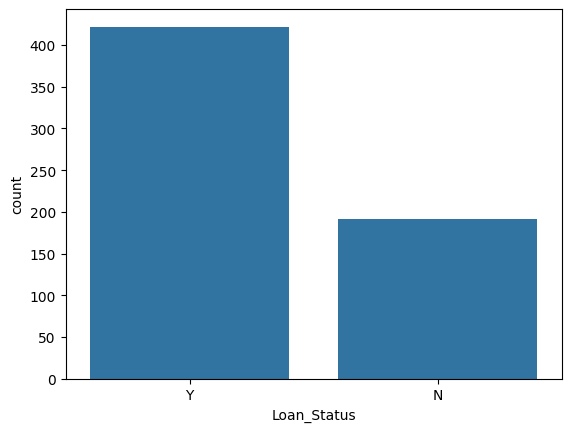

In [23]:
sns.countplot(x='Loan_Status', data=data)

<Axes: xlabel='Gender', ylabel='count'>

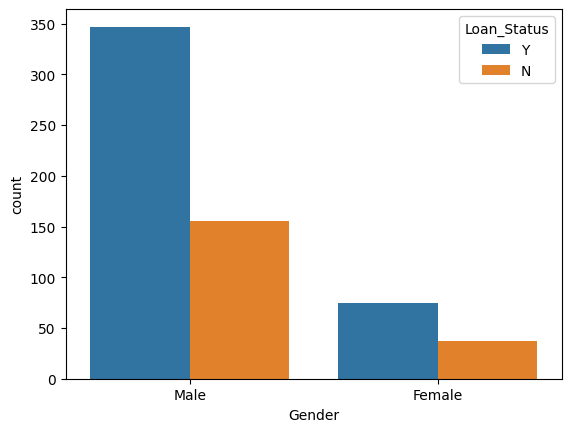

In [28]:
sns.countplot(x='Gender', hue='Loan_Status', data=data)

In [30]:
# Convert categorical variables to numeric
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for col in categorical_cols:
    data[col] = LabelEncoder().fit_transform(data[col])


In [31]:

# Feature scaling
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
data[numerical_cols] = StandardScaler().fit_transform(data[numerical_cols])


In [32]:

# Drop Loan_ID
data.drop('Loan_ID', axis=1, inplace=True)

In [33]:
# Calculate the correlation matrix
corr_matrix = data.corr()

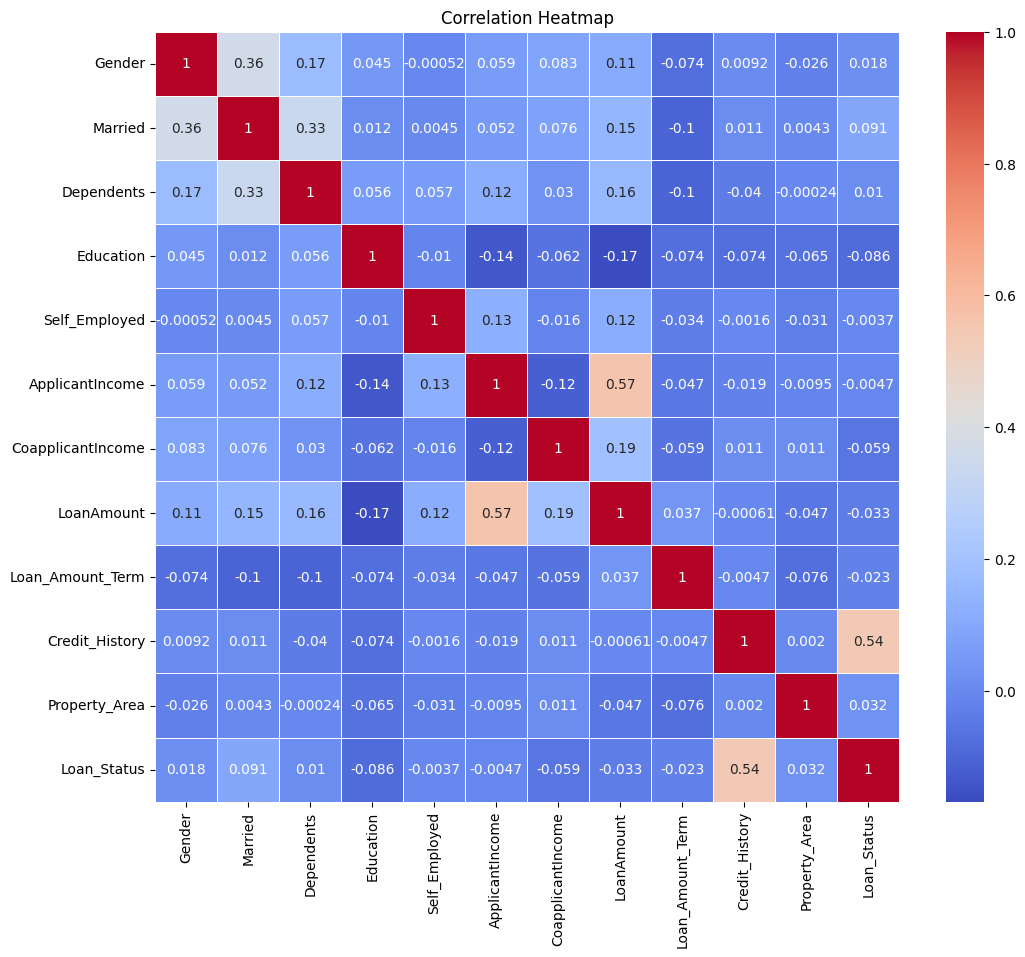

In [34]:
# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

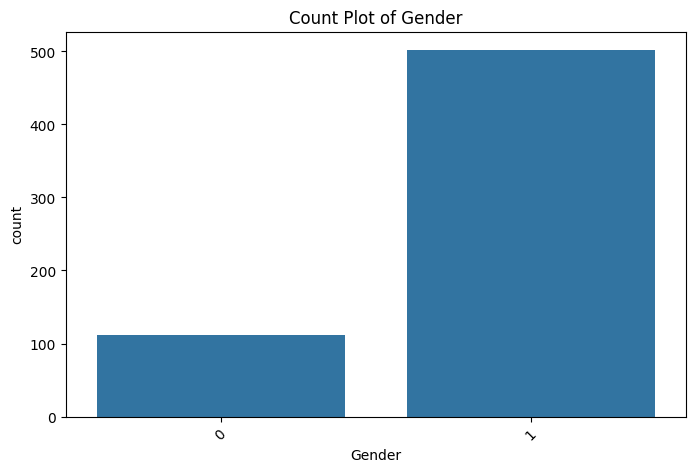

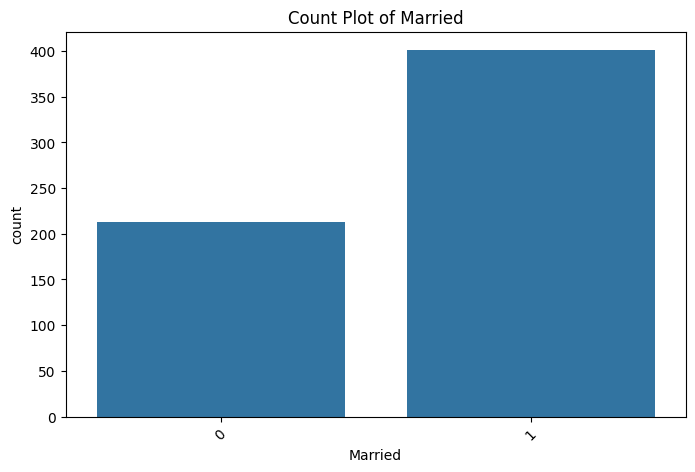

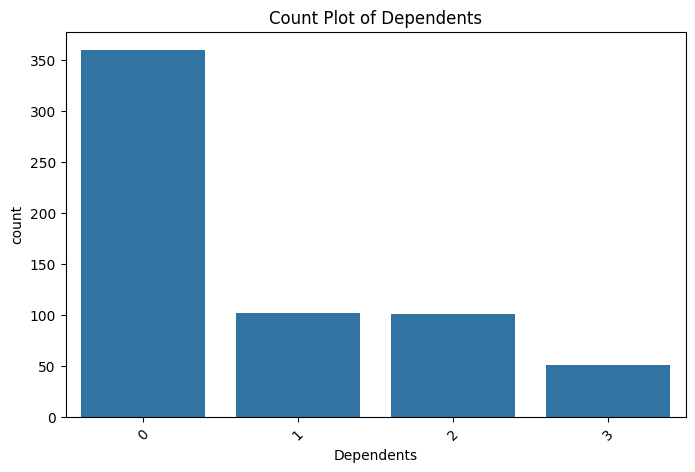

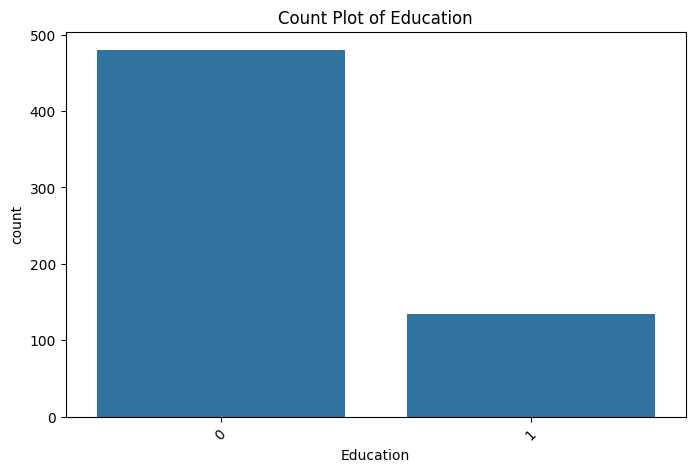

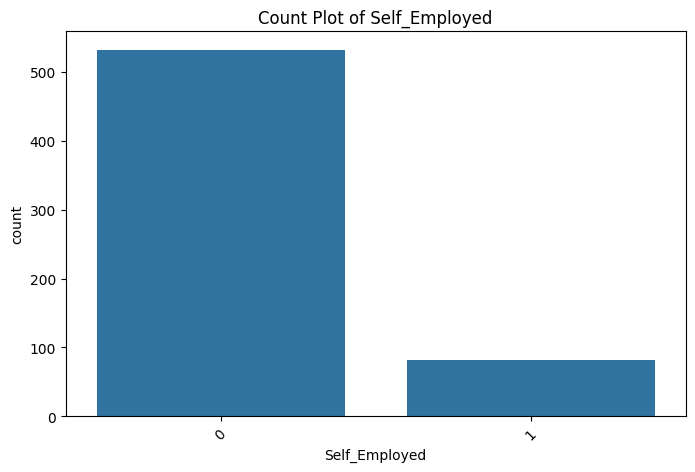

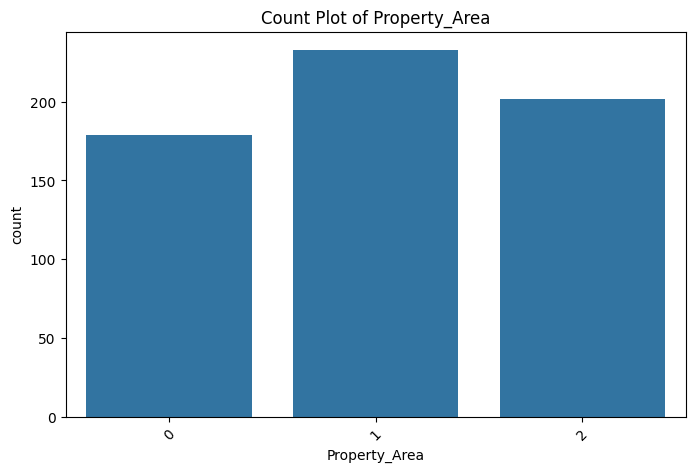

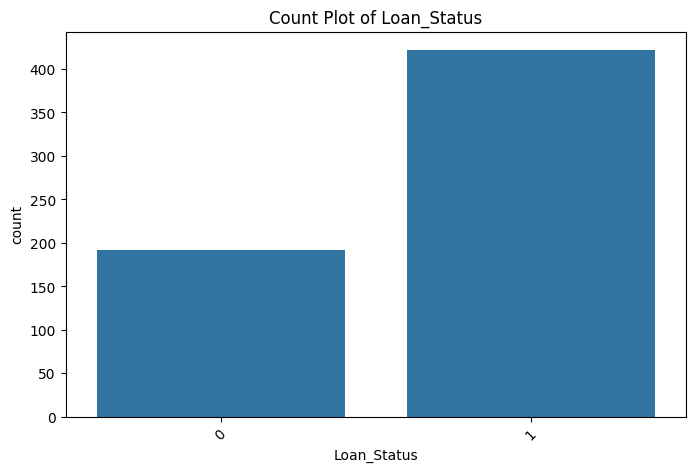

In [35]:
# 1. Bar Plot for Categorical Features
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, data=data)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.show()


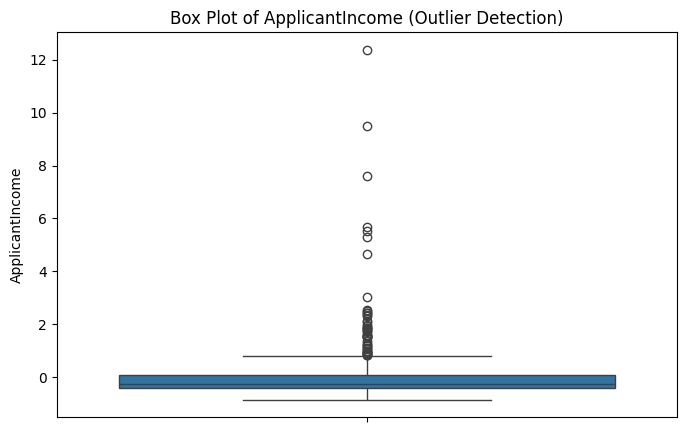

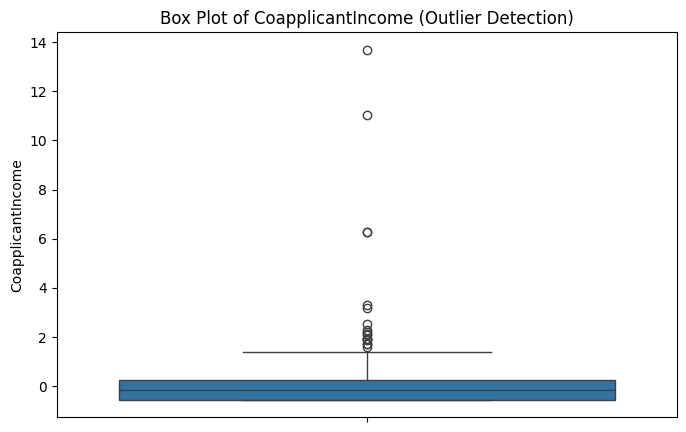

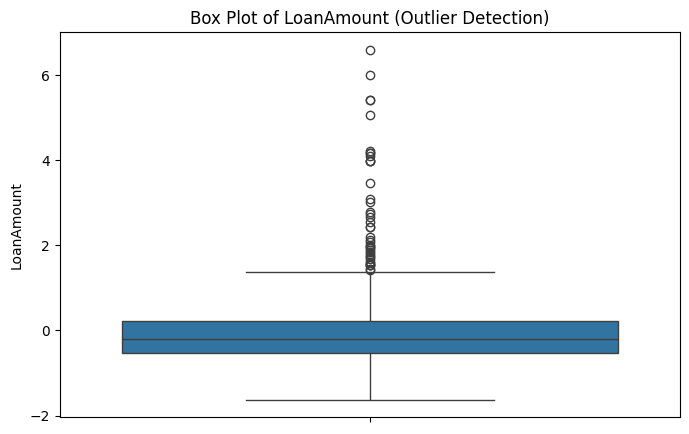

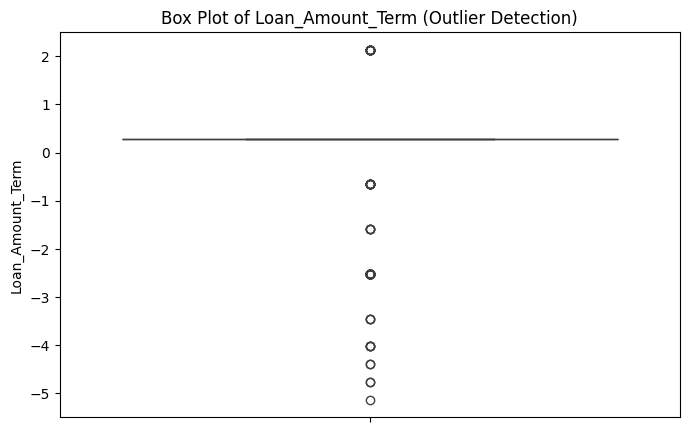

In [36]:

# 2. Box Plot for Outlier Detection in Numerical Features
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=col, data=data)
    plt.title(f'Box Plot of {col} (Outlier Detection)')
    plt.show()


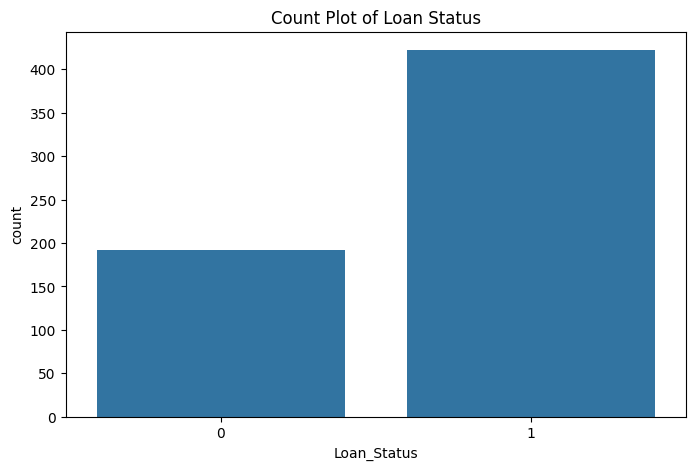

In [37]:

# 3. Count Plot of Target Variable
plt.figure(figsize=(8, 5))
sns.countplot(x='Loan_Status', data=data)
plt.title('Count Plot of Loan Status')
plt.show()

In [38]:

# Convert categorical variables to numeric
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for col in categorical_cols:
    data[col] = LabelEncoder().fit_transform(data[col])


In [39]:

# Feature scaling
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
data[numerical_cols] = StandardScaler().fit_transform(data[numerical_cols])


In [41]:

# Split data into features (X) and target (y)
X = data.drop('Loan_Status', axis=1)
y = data['Loan_Status']


In [42]:

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [43]:

# --- Models ---

# 1. Linear Regression (for regression)
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred_linear)
print("Linear Regression Mean Squared Error:", mse)


Linear Regression Mean Squared Error: 0.1661135058764572


In [44]:

# Convert to binary predictions for classification metrics
y_pred_linear_binary = [1 if p >= 0.5 else 0 for p in y_pred_linear]
accuracy_linear = accuracy_score(y_test, y_pred_linear_binary)
print("Linear Regression Accuracy:", accuracy_linear)
print("Classification Report for Linear Regression:\n", classification_report(y_test, y_pred_linear_binary))


Linear Regression Accuracy: 0.7886178861788617
Classification Report for Linear Regression:
               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [45]:

# ---  ROC Curve for Linear Regression ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_linear)  # Using the continuous predictions
roc_auc = auc(fpr, tpr)
print(f"Linear Regression AUC: {roc_auc:.4f}")


Linear Regression AUC: 0.7384


In [46]:


# 2. Logistic Regression (for classification)
logistic_model = LogisticRegression(random_state=42, solver='liblinear')
logistic_model.fit(X_train, y_train)
y_pred_logistic = logistic_model.predict(X_test)
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
print("Logistic Regression Accuracy:", accuracy_logistic)
print("Classification Report for Logistic Regression:\n", classification_report(y_test, y_pred_logistic))


Logistic Regression Accuracy: 0.7886178861788617
Classification Report for Logistic Regression:
               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [47]:

# --- ROC Curve for Logistic Regression ---
fpr, tpr, thresholds = roc_curve(y_test, logistic_model.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)
print(f"Logistic Regression AUC: {roc_auc:.4f}")



Logistic Regression AUC: 0.7369


In [48]:

# 3. KNN (for classification)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", accuracy_knn)
print("Classification Report for KNN:\n", classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.7560975609756098
Classification Report for KNN:
               precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123



In [49]:

# --- ROC Curve for KNN ---
fpr, tpr, thresholds = roc_curve(y_test, knn_model.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)
print(f"KNN AUC: {roc_auc:.4f}")


KNN AUC: 0.7013


In [50]:
# --- Model Training (XGBoost) ---
import xgboost as xgb


In [51]:
from sklearn.metrics import accuracy_score, classification_report


In [52]:

# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)  # Suppress the warning


In [55]:

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
accuracy_xgb=accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7398373983739838
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.47      0.56        43
           1       0.76      0.89      0.82        80

    accuracy                           0.74       123
   macro avg       0.72      0.68      0.69       123
weighted avg       0.73      0.74      0.73       123



c:\Users\91961\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [13:08:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [57]:
# --- ROC Curve for XGBoost ---
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, xgb_model.predict_proba(X_test)[:, 1])
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
print(f"XGBoost AUC: {roc_auc_xgb:.4f}")

XGBoost AUC: 0.7262


In [58]:

model_performance = {
    "Linear Regression": {"Accuracy": accuracy_linear, "MSE": mse, "AUC": roc_auc},
    "Logistic Regression": {"Accuracy": accuracy_logistic, "AUC": roc_auc},
    "KNN": {"Accuracy": accuracy_knn, "AUC": roc_auc},
    "XGBoost": {"Accuracy": accuracy_xgb, "AUC": roc_auc_xgb}  # Add XGBoost here
}

print("\nModel Performance Comparison:")
for model, metrics in model_performance.items():
    print(f"--- {model} ---")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")



Model Performance Comparison:
--- Linear Regression ---
Accuracy: 0.7886
MSE: 0.1661
AUC: 0.7013
--- Logistic Regression ---
Accuracy: 0.7886
AUC: 0.7013
--- KNN ---
Accuracy: 0.7561
AUC: 0.7013
--- XGBoost ---
Accuracy: 0.7398
AUC: 0.7262


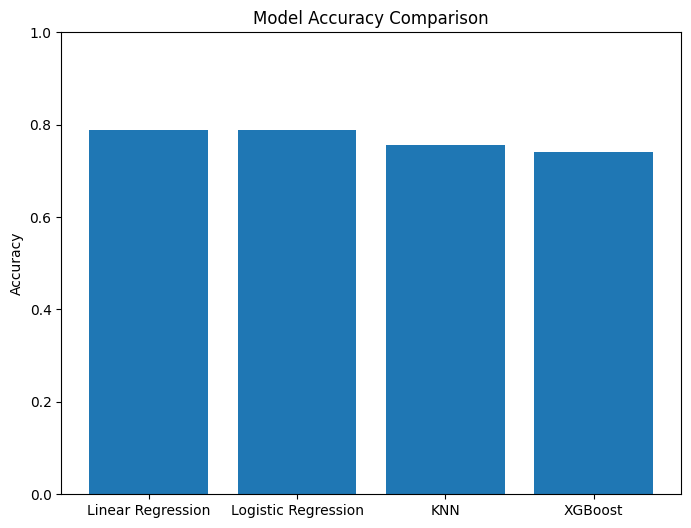

In [59]:

# --- Visualization ---

# Accuracy Comparison
plt.figure(figsize=(8, 6))
plt.bar(model_performance.keys(), [metrics.get("Accuracy", 0) for metrics in model_performance.values()])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()


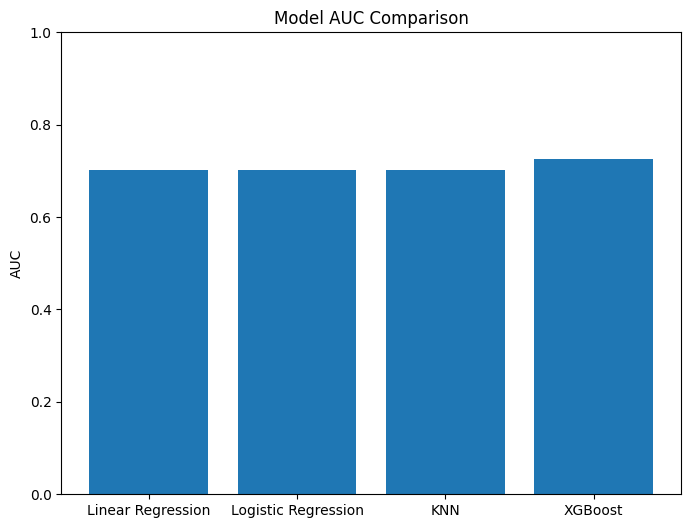

In [ ]:

# AUC Comparison
plt.figure(figsize=(8, 6))
plt.bar(model_performance.keys(), [metrics.get("AUC", 0) for metrics in model_performance.values()])
plt.title("Model AUC Comparison")
plt.ylabel("AUC")
plt.ylim(0, 1)
plt.show()

In [69]:
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, precision_score, recall_score, f1_score

In [62]:

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include='object').columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()


In [63]:

# Numerical pipeline
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('labelencoder', LabelEncoder())
])

# Column Transformer
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])


In [64]:

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit and Transform
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


In [65]:

# --- Model Training and Evaluation ---

# 1. Logistic Regression
logistic_model = LogisticRegression(solver='liblinear', random_state=42)
logistic_model.fit(X_train, y_train)
y_pred_logistic = logistic_model.predict(X_test)

# 2. KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

# 3. XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)


c:\Users\91961\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [13:35:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [67]:

# --- Evaluation Metrics ---

def evaluate_model(y_true, y_pred, model_name="Model"):
    """Calculates and returns various evaluation metrics."""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)  # Assuming binary classification
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_pred)  # Simple ROC for binary case
    roc_auc = auc(fpr, tpr)
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "FPR": fpr,
        "TPR": tpr,
        "AUC": roc_auc
    }


In [70]:

logistic_metrics = evaluate_model(y_test, y_pred_logistic, "Logistic Regression")
knn_metrics = evaluate_model(y_test, y_pred_knn, "KNN")
xgb_metrics = evaluate_model(y_test, y_pred_xgb, "XGBoost")


In [71]:

# --- Visualization ---

def plot_metric(model_metrics, metric_name, ylim=None):
    """Plots a bar chart for a specific metric across models."""
    plt.figure(figsize=(8, 5))
    models = [m["Model"] for m in model_metrics]
    values = [m[metric_name] for m in model_metrics]
    plt.bar(models, values)
    plt.title(f"Model {metric_name} Comparison")
    plt.ylabel(metric_name)
    if ylim:
        plt.ylim(ylim)
    plt.show()


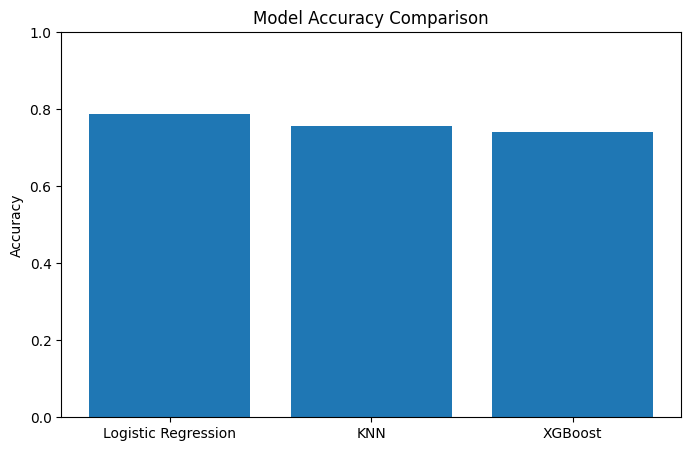

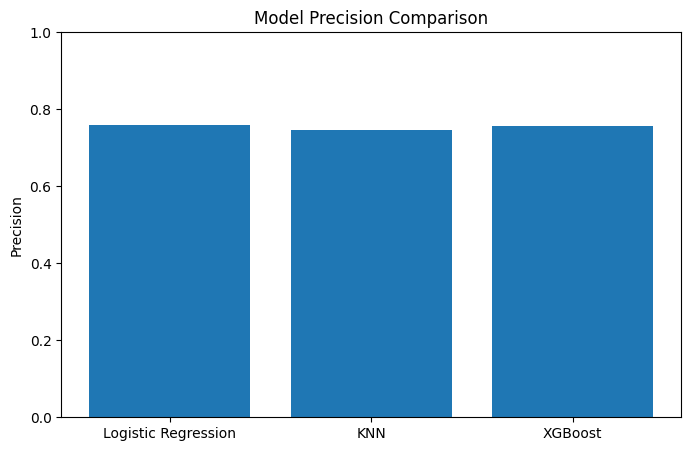

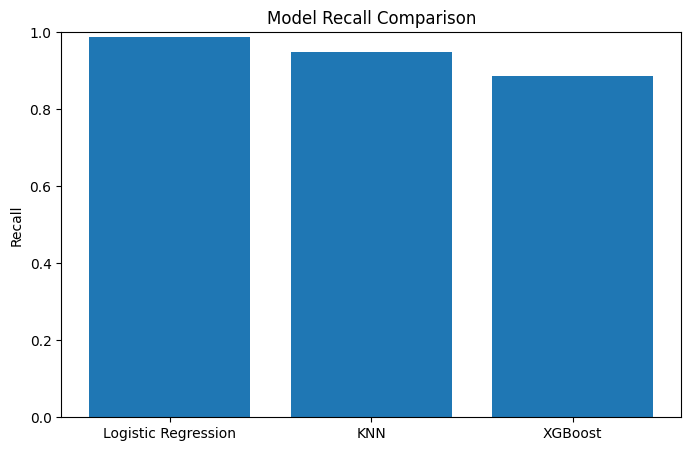

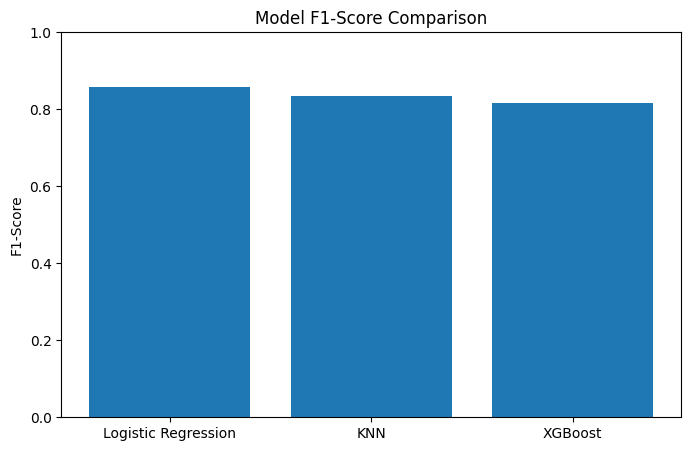

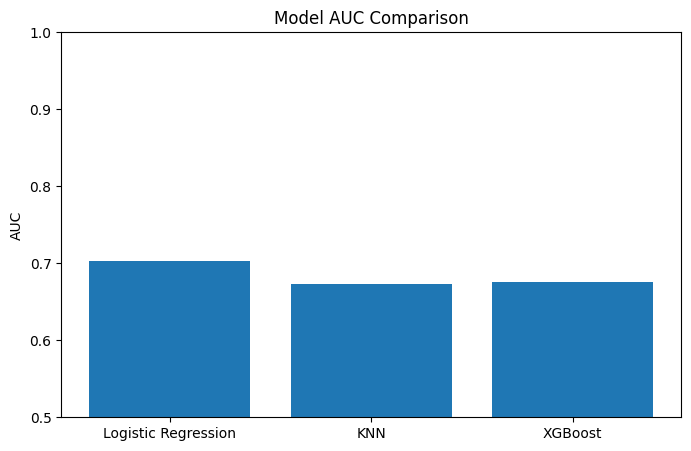

In [72]:

# Plotting metrics
plot_metric([logistic_metrics, knn_metrics, xgb_metrics], "Accuracy", ylim=(0, 1))
plot_metric([logistic_metrics, knn_metrics, xgb_metrics], "Precision", ylim=(0, 1))
plot_metric([logistic_metrics, knn_metrics, xgb_metrics], "Recall", ylim=(0, 1))
plot_metric([logistic_metrics, knn_metrics, xgb_metrics], "F1-Score", ylim=(0, 1))
plot_metric([logistic_metrics, knn_metrics, xgb_metrics], "AUC", ylim=(0.5, 1))  # Adjust ylim for AUC


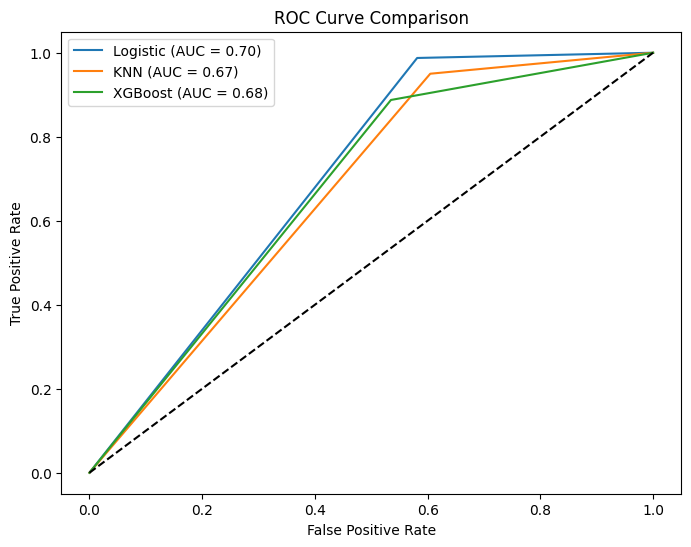

In [73]:

# ROC Curve Visualization (Separate plot for clarity)
plt.figure(figsize=(8, 6))
plt.plot(logistic_metrics["FPR"], logistic_metrics["TPR"], label=f'Logistic (AUC = {logistic_metrics["AUC"]:.2f})')
plt.plot(knn_metrics["FPR"], knn_metrics["TPR"], label=f'KNN (AUC = {knn_metrics["AUC"]:.2f})')
plt.plot(xgb_metrics["FPR"], xgb_metrics["TPR"], label=f'XGBoost (AUC = {xgb_metrics["AUC"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()